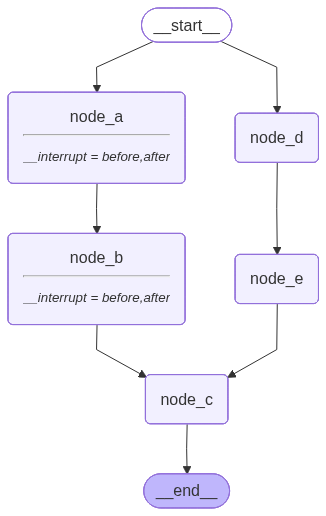

In [2]:
from typing import TypedDict


from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger

#1. 声明状态
class OverAllState(TypedDict):
    final_res:str

#2. 声明节点
def node_a(state:OverAllState)->OverAllState:
    logger.info("node_a被执行")
    return {
        "final_res":"node_a运行的中间结果"
    }

def node_b(state:OverAllState)->OverAllState:
    logger.info("node_b被执行")
    return {
        "final_res":"node_b运行的中间结果"
    }

def node_c(state:OverAllState)->OverAllState:
    logger.info("node_c被执行")
    return {
        "final_res":"node_c运行的结果"
    }

def node_d(state:OverAllState)->OverAllState:
    logger.info("node_d被执行")
    return {}

def node_e(state:OverAllState)->OverAllState:
    logger.info("node_e被执行")
    return {}

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

builder.add_edge(START,"node_a")
builder.add_edge(START,"node_d")
builder.add_edge("node_a","node_b")
builder.add_edge("node_d","node_e")
builder.add_edge("node_b","node_c")
builder.add_edge("node_e","node_c")

builder.add_edge("node_c",END)

#4. 检查点后端存储
checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["node_a","node_b"],
    interrupt_after=["node_a","node_b"]
)

from IPython.display import display
display(graph)

config = {"configurable":{"thread_id":"123"}}


In [3]:
logger.info("==========第一次执行==============")
first_res = graph.invoke({},config=config)
logger.info("第一次执行结果:{}",first_res)

2026-07-11 10:59:42.622 | INFO     | __main__:<module>:1 - ==========第一次执行==============
2026-07-11 10:59:42.635 | INFO     | __main__:<module>:3 - 第一次执行结果:None


In [4]:
logger.info("==========第二次执行==============")
#恢复中断执行需要填写状态为None
second_res = graph.invoke(None,config=config)
logger.info("第二次执行结果:{}",second_res)

2026-07-11 11:00:06.252 | INFO     | __main__:<module>:1 - ==========第二次执行==============
2026-07-11 11:00:06.254 | INFO     | __main__:node_a:14 - node_a被执行
2026-07-11 11:00:06.256 | INFO     | __main__:node_d:32 - node_d被执行
2026-07-11 11:00:06.260 | INFO     | __main__:<module>:4 - 第二次执行结果:{'final_res': 'node_a运行的中间结果'}


In [5]:
logger.info("==========第三次执行==============")
#恢复中断执行需要填写状态为None
res3 = graph.invoke(None,config=config)
logger.info("第三次执行结果:{}",res3)

2026-07-11 11:00:59.151 | INFO     | __main__:<module>:1 - ==========第三次执行==============
2026-07-11 11:00:59.153 | INFO     | __main__:node_b:20 - node_b被执行
2026-07-11 11:00:59.156 | INFO     | __main__:node_e:36 - node_e被执行
2026-07-11 11:00:59.160 | INFO     | __main__:<module>:4 - 第三次执行结果:{'final_res': 'node_b运行的中间结果'}


In [6]:
logger.info("==========第四次执行==============")
#恢复中断执行需要填写状态为None
res4 = graph.invoke(None,config=config)
logger.info("第四次执行结果:{}",res4)


2026-07-11 11:01:10.910 | INFO     | __main__:<module>:1 - ==========第四次执行==============
2026-07-11 11:01:10.911 | INFO     | __main__:node_c:26 - node_c被执行
2026-07-11 11:01:10.913 | INFO     | __main__:<module>:4 - 第四次执行结果:{'final_res': 'node_c运行的结果'}
